# Ayudantía 13 - SQL 

## Nicolás Olate Orellana

### Introducción

Este ejercicio permite practicar la exploración de datos, modelación de bases de datos relacionales y la carga de datos desde un archivo CSV a una base de datos relacional en Python. Se trabajará con datos de vehículos que incluyen detalles sobre el fabricante, el modelo, las características del vehículo, el vendedor, el precio de venta y la fecha de la transacción.

### Descripción de los Datos

Cada registro en el archivo CSV contiene la siguiente información:

- **year**: Año de fabricación del vehículo.
- **make**: Marca o fabricante del vehículo.
- **model**: Modelo específico del vehículo.
- **trim**: Designación adicional del modelo.
- **body**: Tipo de carrocería (e.g., SUV, Sedan).
- **transmission**: Tipo de transmisión (e.g., automática).
- **vin**: Número de Identificación del Vehículo (único por vehículo).
- **state**: El estado de EE. UU. donde está registrado el vehículo.
- **condition**: Condición del vehículo en escala numérica.
- **odometer**: Distancia recorrida por el vehículo en millas.
- **color**: Color exterior del vehículo.
- **interior**: Tipo o color del interior del vehículo.
- **seller**: Nombre del vendedor del vehículo.
- **mmr**: Valor de referencia del mercado (Manheim Market Report).
- **sellingprice**: Precio de venta del vehículo.
- **saledate**: Fecha de la venta del vehículo.

## Misiones

### Misión 0: Análisis preliminar de datos (0.6 pts)

Realice las siguientes visualizaciones y cálculos para explorar el conjunto de datos y las relaciones entre ellos:

1. **Distribución de vehículos por año de fabricación**: Visualice el número de vehículos según su año de fabricación en un histograma.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

vehiculos = pd.read_csv('vehicles.csv')

vehiculos.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2014,Kia,Forte,LX,Sedan,automatic,knafx4a64e5093418,nc,29.0,38339.0,red,black,avis corporation,11350.0,11500.0,Tue Feb 03 2015 01:15:00 GMT-0800 (PST)
1,2010,Audi,A4,2.0T Premium,Sedan,automatic,wauafafl4an066787,fl,46.0,46120.0,silver,black,lauderdale infiniti,14350.0,16600.0,Fri Dec 19 2014 09:35:00 GMT-0800 (PST)
2,2011,Toyota,Camry,LE,Sedan,automatic,4t1bf3ek3bu171593,ga,19.0,55958.0,gray,gray,capital one auto finance,10700.0,9000.0,Tue Jan 20 2015 01:30:00 GMT-0800 (PST)
3,2007,NaN,NaN,NaN,NaN,automatic,5tfrv54117x028139,ca,25.0,67044.0,gray,gray,e/e auto wholesale,14650.0,19500.0,Thu Jan 22 2015 04:00:00 GMT-0800 (PST)
4,2014,Kia,Forte,LX,Sedan,NaN,knafx4a66e5208858,ga,46.0,10386.0,silver,black,kia motors america inc,12850.0,12800.0,Thu Jan 08 2015 02:00:00 GMT-0800 (PST)


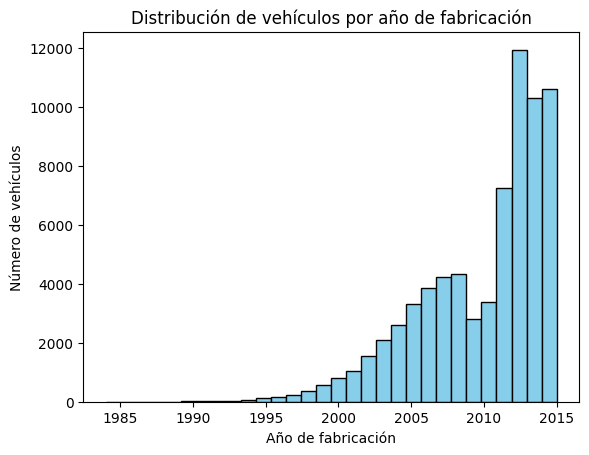

In [6]:
vehiculos['year'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de vehículos por año de fabricación')
plt.xlabel('Año de fabricación')
plt.ylabel('Número de vehículos')
plt.show()


2. **Comparación de precios de venta vs. valor de mercado (MMR)**: Cree un gráfico para observar la relación entre venta y MMR. Determine el porcentaje de vehículos que se venden por encima y por debajo de su valor de mercado.

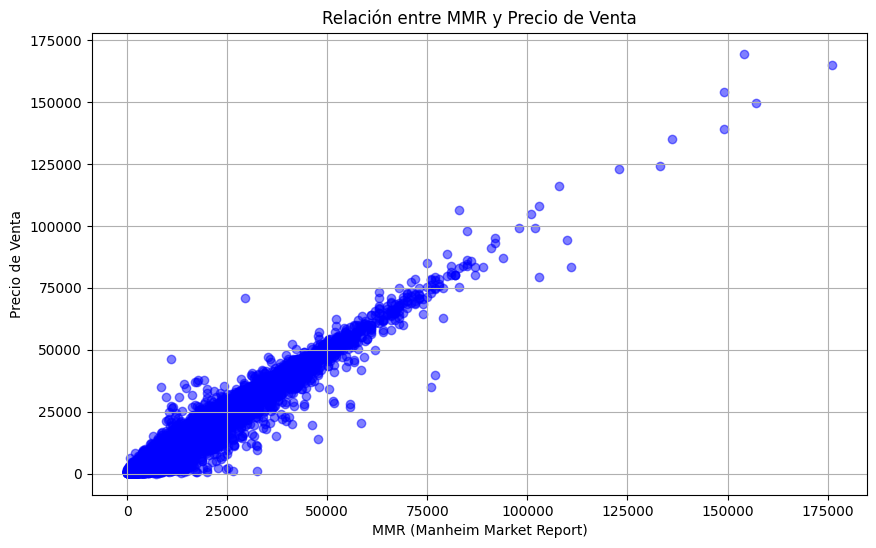

In [7]:
# Crear un gráfico de dispersión para visualizar la relación entre `mmr` y `sellingprice`
plt.figure(figsize=(10, 6))
plt.scatter(vehiculos['mmr'], vehiculos['sellingprice'], alpha=0.5, color='blue')
plt.title('Relación entre MMR y Precio de Venta')
plt.xlabel('MMR (Manheim Market Report)')
plt.ylabel('Precio de Venta')
plt.grid(True)
plt.show()


In [8]:

#  Contar vehículos donde el precio de venta es mayor que el valor de mercado
vehiculos_mayor_mmr = vehiculos[vehiculos['sellingprice'] > vehiculos['mmr']].shape[0]

# shape[0]: devuelve el número de registros que cumplen con la condición

# Contar vehículos donde el precio de venta es menor que el valor de mercado
vehiculos_menor_mmr = vehiculos[vehiculos['sellingprice'] < vehiculos['mmr']].shape[0]

# Calcular el total de registros para obtener el porcentaje
total_vehiculos = vehiculos.shape[0]

# Calcular porcentajes
porcentaje_mayor_mmr = (vehiculos_mayor_mmr / total_vehiculos) * 100
porcentaje_menor_mmr = (vehiculos_menor_mmr / total_vehiculos) * 100

print(f"Porcentaje de vehículos vendidos por encima de su valor de mercado: {porcentaje_mayor_mmr:.2f}%")
print(f"Porcentaje de vehículos vendidos por debajo de su valor de mercado: {porcentaje_menor_mmr:.2f}%")
print(f"Porcentaje de vehículos vigual que su valor de mercado: {100 - porcentaje_menor_mmr-porcentaje_mayor_mmr:.2f}%")

Porcentaje de vehículos vendidos por encima de su valor de mercado: 43.64%
Porcentaje de vehículos vendidos por debajo de su valor de mercado: 54.40%
Porcentaje de vehículos vigual que su valor de mercado: 1.96%


3. **Frecuencia de Colores Exteriores e Interiores**: Determine cuáles son los 5 colores interiores y exteriores más comunes en los vehículos de forma individual. Luego indique las 3 combinaciones de colores interiores y exteriores más populares.

In [9]:
# Frecuencia de colores exteriores
frecuencia_colores_ext = vehiculos['color'].value_counts().head(5)
print('Frecuencia de colores exteriores')
print(frecuencia_colores_ext)

print('\n')
# Frecuencia de colores interiores
frecuencia_colores_int = vehiculos['interior'].value_counts().head(5)
print('Frecuencia de colores interiores')
print(frecuencia_colores_int)

print('\n')

# Frecuencia de combinaciones de colores interiores y exteriores
# size(): devuelve el número de registros por grupo
# reset_index(): convierte el índice en columnas
frecuencia_colores = vehiculos.groupby(['color', 'interior']).size().reset_index(name='frecuencia')
# Ordenar por frecuencia en orden descendente
frecuencia_colores = frecuencia_colores.sort_values(by='frecuencia', ascending=False)
print('Frecuencia de combinaciones de colores interiores y exteriores')
print(frecuencia_colores.head(3))


Frecuencia de colores exteriores
color
black     14425
white     13225
gray      10782
silver    10543
blue       6749
Name: count, dtype: int64


Frecuencia de colores interiores
interior
black    29661
gray     22797
beige     7430
tan       6072
—         3848
Name: count, dtype: int64


Frecuencia de combinaciones de colores interiores y exteriores
      color interior  frecuencia
9     black    black        7680
79     gray    black        5127
148  silver    black        4873



### Misión 1: Modelación de Entidades (1.2 pts)

En base a la estructura de los datos, modele las entidades y las relaciones entre ellas, incluyendo las restricciones de integridad correspondientes. A continuación, se indican las tablas a modelar:

- **Vehicles**: Entidad principal de los vehículos, que incluye el año de fabricación, el VIN y detalles específicos como color, interior, condición, etc.
- **Manufacturers**: Almacena información de cada fabricante (make).
- **Models**: Incluye los modelos de vehículos, vinculados a cada fabricante.
- **States**: Contiene los estados de registro, permitiendo filtrar por ubicación.
- **Sellers**: Registra la información del vendedor de cada vehículo.
- **Sales**: Contiene la información de cada venta realizada, incluyendo el valor de mercado (mmr), precio de venta y fecha.


In [10]:

# ### Misión 1: Modelación de Entidades (1.2 pts)

# A continuación, se presenta el modelo entidad-relación (ER) simplificado para el caso de estudio:
import sqlite3

# Crear una conexión a la base de datos (esto creará un archivo .db si no existe)
conn = sqlite3.connect('vehicles.db')

# Crear un cursor para ejecutar comandos SQL
cursor = conn.cursor()

# Crear la tabla Manufacturers
# if not exists: para evitar errores si la tabla ya existe
# primary key: define la columna como clave primaria
# not null: indica que la columna no puede tener valores nulos
cursor.execute("""
CREATE TABLE IF NOT EXISTS Manufacturers (
    manufacturer_id INTEGER PRIMARY KEY,
    make TEXT NOT NULL
);
""")

# Crear la tabla Models
# foreign key: define una clave foránea que referencia a otra tabla
# models tiene un manufacturer_id que referencia a la tabla Manufacturers
cursor.execute("""
CREATE TABLE IF NOT EXISTS Models (
    model_id INTEGER PRIMARY KEY,
    model_name TEXT NOT NULL,
    trim TEXT,
    manufacturer_id INTEGER,
    FOREIGN KEY (manufacturer_id) REFERENCES Manufacturers (manufacturer_id)
);
""")

# Crear la tabla States
# not null: indica que la columna no puede tener valores nulos (integridad)
cursor.execute("""
CREATE TABLE IF NOT EXISTS States (
    state_id INTEGER PRIMARY KEY,
    state TEXT NOT NULL
);
""")

# Crear la tabla Sellers
cursor.execute("""
CREATE TABLE IF NOT EXISTS Sellers (
    seller_id INTEGER PRIMARY KEY,
    seller_name TEXT NOT NULL
);
""")

# Crear la tabla Vehicles
# vin: clave primaria
# model_id: clave foránea que referencia a la tabla Models
# state_id: clave foránea que referencia a la tabla States
# seller_id: clave foránea que referencia a la tabla Sellers
cursor.execute("""
CREATE TABLE IF NOT EXISTS Vehicles (
    vin TEXT PRIMARY KEY,
    year INTEGER,
    body TEXT,
    transmission TEXT,
    condition INTEGER,
    odometer INTEGER,
    color TEXT,
    interior TEXT,
    model_id INTEGER,
    state_id INTEGER,
    seller_id INTEGER,
    FOREIGN KEY (model_id) REFERENCES Models (model_id),
    FOREIGN KEY (state_id) REFERENCES States (state_id),
    FOREIGN KEY (seller_id) REFERENCES Sellers (seller_id)
);
""")

# Crear la tabla Sales  
# sale_id: clave primaria
# vin: clave foránea que referencia a la tabla Vehicles
cursor.execute("""
CREATE TABLE IF NOT EXISTS Sales (
    sale_id INTEGER PRIMARY KEY,
    vin TEXT,
    mmr REAL,
    sellingprice REAL,
    saledate DATE,
    FOREIGN KEY (vin) REFERENCES Vehicles (vin)
);
""")




### Misión 2: Carga de Datos (1.2 pts)

Una vez creada la estructura de las tablas, extraiga los datos del archivo CSV y cárguelos en las tablas correspondientes. Recuerde mantener las relaciones y las restricciones de integridad entre los datos cargados. Finalmente, muestre la información de las tablas creadas.


In [11]:
# en teoria deberia existir previamente una limpieza de datos para que no existan problemas con valores nulos o duplicados.

# dropna(): elimina registros con valores nulos
vehiculos = vehiculos.dropna(subset=['make'])

# Insertar marcas sin repetir en la tabla Manufacturers
# unique(): devuelve los valores únicos de una columna
for make in vehiculos['make'].unique():
    # ? es un placeholder para el valor de la variable
    # execute(): ejecuta un comando SQL
    cursor.execute("INSERT INTO Manufacturers (make) VALUES (?)", (make,))

# Confirmar los cambios
conn.commit()

In [12]:
# Visualizar los primeros 100 registros de la tabla Manufacturers
cursor.execute("""
SELECT * FROM Manufacturers LIMIT 100
""")
manufacturers = cursor.fetchall()
print(manufacturers)


[(1, 'Kia'), (2, 'Audi'), (3, 'Toyota'), (4, 'Volvo'), (5, 'Dodge'), (6, 'Ford'), (7, 'Chevrolet'), (8, 'Honda'), (9, 'Buick'), (10, 'Mercury'), (11, 'BMW'), (12, 'Jeep'), (13, 'Mercedes-Benz'), (14, 'Cadillac'), (15, 'Lincoln'), (16, 'Nissan'), (17, 'chevrolet'), (18, 'Jaguar'), (19, 'Infiniti'), (20, 'Ram'), (21, 'Mazda'), (22, 'Lexus'), (23, 'Hyundai'), (24, 'GMC'), (25, 'Volkswagen'), (26, 'Suzuki'), (27, 'Saturn'), (28, 'Chrysler'), (29, 'dodge'), (30, 'Acura'), (31, 'Mitsubishi'), (32, 'Subaru'), (33, 'Bentley'), (34, 'FIAT'), (35, 'Scion'), (36, 'Pontiac'), (37, 'mercury'), (38, 'MINI'), (39, 'Land Rover'), (40, 'Porsche'), (41, 'Saab'), (42, 'smart'), (43, 'hyundai'), (44, 'ford'), (45, 'mazda'), (46, 'HUMMER'), (47, 'Oldsmobile'), (48, 'mitsubishi'), (49, 'Plymouth'), (50, 'lexus'), (51, 'volkswagen'), (52, 'gmc'), (53, 'nissan'), (54, 'cadillac'), (55, 'chrysler'), (56, 'honda'), (57, 'porsche'), (58, 'bmw'), (59, 'Maserati'), (60, 'land rover'), (61, 'toyota'), (62, 'lincoln

In [13]:
# Poblar la tabla Models 
# Asegurarte de que no haya valores nulos en 'model_name' y 'make'
models = vehiculos.dropna(subset=['model', 'make'])

# En este caso tenemos que agregar una foreign key, por lo que necesitamos el manufacturer_id.
for _, row in models.iterrows():
    # Obtener el manufacturer_id de la marca
    # fetchone(): obtiene la primera fila del resultado
    # row['make']: valor de la columna 'make' en la fila actual
    cursor.execute("SELECT manufacturer_id FROM Manufacturers WHERE make = ?", (row['make'],))
    # manufacturer_id es una tupla (manufacturer_id,)
    manufacturer_id = cursor.fetchone()

    # Si manufacturer_id es None, no se inserta el modelo
    if manufacturer_id:
        manufacturer_id = manufacturer_id[0]  # Extraer el manufacturer_id de la tupla

        # Insertar el modelo en la tabla Models
        cursor.execute("""
        INSERT INTO Models (model_name, trim, manufacturer_id) 
        VALUES (?, ?, ?)
        """, (row['model'], row.get('trim', None), manufacturer_id))

conn.commit()




In [14]:
# Verificar los primeros 10 registros de la tabla Models
cursor.execute("""
SELECT * FROM Models LIMIT 20
""")
models = cursor.fetchall()
print(models)

[(1, 'Forte', 'LX', 1), (2, 'A4', '2.0T Premium', 2), (3, 'Camry', 'LE', 3), (4, 'Forte', 'LX', 1), (5, 'XC90', '3.2', 4), (6, 'Grand Caravan', 'SE', 5), (7, 'F-150', 'XL', 6), (8, 'Cruze', 'LTZ', 7), (9, 'Avenger', 'SE', 5), (10, 'Civic', 'LX', 8), (11, 'Focus', 'SE', 6), (12, 'Enclave', 'CXL1', 9), (13, 'Optima', 'SX', 1), (14, 'Taurus', 'Limited', 6), (15, 'Tahoe', 'LT', 7), (16, 'Mountaineer', 'Convenience', 10), (17, 'Optima', 'LX', 1), (18, 'Malibu', 'LS', 7), (19, 'F-350 Super Duty', 'Lariat', 6), (20, '3 Series', '325i', 11)]


In [15]:
# Asegurarse de que no haya valores nulos en 'state'
vehiculos = vehiculos.dropna(subset=['state'])

# Insertar estados únicos en la tabla States
for state in vehiculos['state'].unique():
    cursor.execute("INSERT OR IGNORE INTO States (state) VALUES (?)", (state,))

conn.commit()



In [16]:
# Visualizar los primeros 10 registros de la tabla States
cursor.execute("""
SELECT * FROM States LIMIT 60
""")
states = cursor.fetchall()
print(states)




[(1, 'nc'), (2, 'fl'), (3, 'ga'), (4, 'mo'), (5, 'oh'), (6, 'ca'), (7, 'nj'), (8, 'tx'), (9, 'pa'), (10, 'ma'), (11, 'tn'), (12, 'md'), (13, 'wa'), (14, 'va'), (15, 'az'), (16, 'ne'), (17, 'mn'), (18, 'nv'), (19, 'mi'), (20, 'sc'), (21, 'il'), (22, 'qc'), (23, 'or'), (24, 'ny'), (25, 'wi'), (26, 'pr'), (27, 'on'), (28, 'la'), (29, 'in'), (30, 'ut'), (31, 'co'), (32, 'hi'), (33, 'ab'), (34, 'ms'), (35, 'ok'), (36, 'nm')]


In [17]:
# # Asegurarte de que no haya valores nulos en 'seller'

vehiculos = vehiculos.dropna(subset=['seller'])

# Insertar vendedores únicos en la tabla Sellers
for seller_name in vehiculos['seller'].unique():
    cursor.execute("INSERT OR IGNORE INTO Sellers (seller_name) VALUES (?)", (seller_name,))
conn.commit()



In [18]:
# Visualizar los primeros 10 registros de la tabla Sellers
cursor.execute("""
SELECT * FROM Sellers LIMIT 30
""")
sellers = cursor.fetchall()
print(sellers)


[(1, 'avis corporation'), (2, 'lauderdale infiniti'), (3, 'capital one auto finance'), (4, 'kia motors america  inc'), (5, 'remarketing by ge/hardy automotive llc'), (6, 'performance chrysler jeep dodge inc'), (7, 'u-haul'), (8, 'gm remarketing'), (9, 'chrysler capital'), (10, 'ahfc/honda lease trust/hvt  inc. eot'), (11, 'ford motor credit company llc'), (12, 'bmw of san antonio'), (13, 'remarketing by ge/space coast credit union'), (14, 'avis budget group'), (15, 'young motors llc'), (16, 'ed morse auto plaza'), (17, 'gm financial leasing'), (18, 'remarketing by ge/budget motor co'), (19, 'quality acceptance'), (20, 'sterling credit corp'), (21, 'the hertz corporation'), (22, 'chrysler group/hertz/pv holding/000gd'), (23, 'boch toyota/scion south'), (24, 'mercedes-benz financial services'), (25, 'primeritus remarketing/aas'), (26, 'daylight auto financing inc'), (27, 'ars/avis budget group'), (28, 'ford motor credit company'), (29, 'boch new to you superstore'), (30, 'nissan-infiniti

In [19]:

# Insertar los vehículos en la tabla Vehicles, ignorando duplicados en vin
for _, row in vehiculos.iterrows():
    # Obtener el model_id del modelo
    cursor.execute("SELECT model_id FROM Models WHERE model_name = ?", (row['model'],))
    model_id = cursor.fetchone()

    # Obtener el state_id del estado
    cursor.execute("SELECT state_id FROM States WHERE state = ?", (row['state'],))
    state_id = cursor.fetchone()

    # Obtener el seller_id del vendedor
    cursor.execute("SELECT seller_id FROM Sellers WHERE seller_name = ?", (row['seller'],))
    seller_id = cursor.fetchone()

    if model_id and state_id and seller_id:
        model_id = model_id[0]  # Extraer el model_id de la tupla
        state_id = state_id[0]  # Extraer el state_id de la tupla
        seller_id = seller_id[0]  # Extraer el seller_id de la tupla

        # Insertar el vehículo en la tabla Vehicles, ignorando duplicados en vin
        cursor.execute("""
        INSERT OR IGNORE INTO Vehicles (vin, year, body, transmission, condition, odometer, color, interior, model_id, state_id, seller_id) 
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (row['vin'], row['year'], row['body'], row['transmission'], row['condition'], row['odometer'], row['color'], row['interior'], model_id, state_id, seller_id))

# Confirmar los cambios
conn.commit()



In [20]:
# Visualizar los primeros 10 registros de la tabla Vehicles
cursor.execute("""
SELECT * FROM Vehicles LIMIT 10
""")
vehicles = cursor.fetchall()
print(vehicles)

[('knafx4a64e5093418', 2014, 'Sedan', 'automatic', 29, 38339, 'red', 'black', 1, 1, 1), ('wauafafl4an066787', 2010, 'Sedan', 'automatic', 46, 46120, 'silver', 'black', 2, 2, 2), ('4t1bf3ek3bu171593', 2011, 'Sedan', 'automatic', 19, 55958, 'gray', 'gray', 3, 3, 3), ('knafx4a66e5208858', 2014, 'Sedan', None, 46, 10386, 'silver', 'black', 1, 3, 4), ('yv4cy982881434167', 2008, 'SUV', 'automatic', 32, 69959, 'black', 'gray', 5, 2, 5), ('1d8hn44h68b126134', 2008, 'Minivan', 'automatic', 31, 86322, 'silver', 'black', 6, 4, 6), ('1ftnf1cf8ekd18244', 2014, 'Regular Cab', 'automatic', 39, 15311, 'white', 'gray', 7, 3, 7), ('1g1pg5sb2e7278329', 2014, 'Sedan', 'automatic', 44, 17877, 'red', 'black', 8, 2, 8), ('1c3cdzab8en227635', 2014, 'Sedan', 'automatic', 5, 15107, 'white', 'black', 9, 5, 9), ('2hgfb2f53ch334060', 2012, 'Sedan', 'automatic', 38, 34161, 'silver', 'gray', 10, 6, 10)]


In [21]:

# Asegurarte de que no haya valores nulos en 'vin'
ventas = vehiculos.dropna(subset=['vin'])

# Insertar las ventas en la tabla Sales
for _, row in ventas.iterrows():
    # Obtener el vin del vehículo
    cursor.execute("SELECT vin FROM Vehicles WHERE vin = ?", (row['vin'],))
    vin = cursor.fetchone()

    if vin:
        vin = vin[0]

        # Insertar la venta en la tabla Sales
        cursor.execute("""
        INSERT INTO Sales (vin, mmr, sellingprice, saledate)
        VALUES (?, ?, ?, ?)
        """, (vin, row['mmr'], row['sellingprice'], row['saledate']))

# Confirmar los cambios
conn.commit()

In [22]:
# Confirmar los cambios
conn.commit()

# Visualizar los primeros 10 registros de la tabla Sales
cursor.execute("""
SELECT * FROM Sales LIMIT 10
""")
sales = cursor.fetchall()
print(sales)

[(1, 'knafx4a64e5093418', 11350.0, 11500.0, 'Tue Feb 03 2015 01:15:00 GMT-0800 (PST)'), (2, 'wauafafl4an066787', 14350.0, 16600.0, 'Fri Dec 19 2014 09:35:00 GMT-0800 (PST)'), (3, '4t1bf3ek3bu171593', 10700.0, 9000.0, 'Tue Jan 20 2015 01:30:00 GMT-0800 (PST)'), (4, 'knafx4a66e5208858', 12850.0, 12800.0, 'Thu Jan 08 2015 02:00:00 GMT-0800 (PST)'), (5, 'yv4cy982881434167', 10300.0, 11300.0, 'Fri Jan 16 2015 02:10:00 GMT-0800 (PST)'), (6, '1d8hn44h68b126134', 5375.0, 7700.0, 'Mon Dec 22 2014 11:00:00 GMT-0800 (PST)'), (7, '1ftnf1cf8ekd18244', 18100.0, 18200.0, 'Tue Feb 03 2015 01:30:00 GMT-0800 (PST)'), (8, '1g1pg5sb2e7278329', 12450.0, 12600.0, 'Tue Jun 02 2015 02:15:00 GMT-0700 (PDT)'), (9, '1c3cdzab8en227635', 11950.0, 12600.0, 'Tue Jan 20 2015 04:00:00 GMT-0800 (PST)'), (10, '2hgfb2f53ch334060', 11050.0, 12000.0, 'Thu Jan 15 2015 04:00:00 GMT-0800 (PST)')]


In [23]:

# Ejemplo de consulta SQL
# SELECT: selecciona las columnas a mostrar
# FROM: indica las tablas a unir
# JOIN: une las tablas
# ON: indica la condición de unión
# aca se busca el modelo y el precio de venta

cursor.execute("""
SELECT m.model_name, s.sellingprice
FROM Sales s
JOIN Vehicles v ON s.vin = v.vin
JOIN Models m ON v.model_id = m.model_id
""")


ventas_modelo = cursor.fetchall()
print(ventas_modelo)





[('Forte', 11500.0), ('A4', 16600.0), ('Camry', 9000.0), ('Forte', 12800.0), ('XC90', 11300.0), ('Grand Caravan', 7700.0), ('F-150', 18200.0), ('Cruze', 12600.0), ('Avenger', 12600.0), ('Civic', 12000.0), ('Focus', 9500.0), ('Enclave', 14500.0), ('Optima', 14600.0), ('Taurus', 19500.0), ('Tahoe', 25300.0), ('Mountaineer', 1900.0), ('Optima', 14300.0), ('Malibu', 8200.0), ('F-350 Super Duty', 11200.0), ('3 Series', 2000.0), ('Civic', 1600.0), ('Cruze', 7400.0), ('Cherokee', 18700.0), ('CR-V', 6900.0), ('E-Class', 22750.0), ('Malibu', 8200.0), ('Odyssey', 3000.0), ('Escalade', 8400.0), ('Focus', 12000.0), ('MKS', 19600.0), ('Corolla', 700.0), ('Sorento', 6800.0), ('Leaf', 12300.0), ('Sienna', 6900.0), ('1500', 8800.0), ('MKX', 9700.0), ('Accord', 4000.0), ('Impala', 8900.0), ('Altima', 7000.0), ('XJ', 29500.0), ('Focus', 5000.0), ('Impala', 8600.0), ('Highlander', 4500.0), ('Camry', 12900.0), ('CR-V', 15500.0), ('Express', 18600.0), ('G Sedan', 22750.0), ('Element', 11300.0), ('S-Class',



### Misión 2: Carga de Datos (1.2 pts)

Una vez creada la estructura de las tablas, extraiga los datos del archivo CSV y cárguelos en las tablas correspondientes. Recuerde mantener las relaciones y las restricciones de integridad entre los datos cargados. Finalmente, muestre la información de las tablas creadas.

# Parte 2

Realice web scraping de los sitios Zillow y/o Apartments.com para obtener información de propiedades en arriendo en las ciudades de Los Ángeles, Denver y Nueva York. Guarde la información en DataFrames, almacénela en una base de datos relacional y realice un análisis para identificar los mejores lugares para vivir en base a ciertos criterios.

## Instrucciones

### 1. Extracción de Datos

- Realice scraping en las siguientes páginas web:
  - **Zillow**: `https://www.zillow.com/[ciudad]-[estado]/`
  - **Apartments.com**: `https://www.apartments.com/[ciudad]-[estado]/`

Extraiga los siguientes datos para cada propiedad:

- Precio, número de habitaciones y baños, tipo de propiedad (casa o departamento), superficie, fecha de mudanza, política de mascotas, coordenadas y lista de amenidades principales.

**Nota**: Utilice las librerías que estime convenientes para extraer la información, recuerde tener en cuenta *rate limiters* y considere aplicar distintas técnicas para evitarlos.

**Disclaimer**: En caso de baneo de IP por parte de los sitios, considere utilizar una VPN, requests con diferentes direcciones IP o en última instancia el uso de APIs para extraer los datos.

- Utilice la **Yelp Fusion API** para obtener información sobre gimnasios, supermercados y restaurantes en cada ciudad. Extraiga los datos relevantes, como nombre, dirección, coordenadas geográficas, tipo de servicio y valoración, para cada servicio encontrado.

**Nota**: Para obtener las coordenadas a partir de una dirección, se puede utilizar la API de Nominatim de OpenStreetMap.

### 2. Almacenamiento de Datos

- Cree una base de datos relacional utilizando `sqlite3` en Python y defina un esquema para la base de datos que incluya las siguientes entidades:

  - **Propiedades**
    - `id`: Identificador único de la propiedad
    - `direccion`: Dirección de la propiedad
    - `ciudad`: Ciudad de la propiedad
    - `estado`: Estado de la propiedad
    - `tipo`: Tipo de propiedad (casa, departamento)
    - `coordenadas`: Coordenadas de la propiedad (latitud y longitud)
    - `precio`: Precio de alquiler de la propiedad
    - `habitaciones`: Número de habitaciones
    - `banos`: Número de baños
    - `superficie`: Superficie en pies cuadrados o metros cuadrados
    - `politica mascotas`: Indicación de si se permiten mascotas

  - **Amenidades**
    - `id`: Identificador único de la amenidad
    - `descripcion`: Descripción de la amenidad (por ejemplo, lavandería, aire acondicionado, piscina)

  - **Propiedades Amenidades**
    - `propiedad id`: Identificador de la propiedad (llave foránea de Propiedades)
    - `amenidad id`: Identificador de la amenidad (llave foránea de Amenidades)

  - **Servicios**
    - `id`: Identificador único del servicio
    - `tipo servicio`: Tipo de servicio (gimnasio, supermercado, restaurante)
    - `nombre`: Nombre del servicio
    - `direccion`: Dirección del servicio
    - `valoracion`: Valoración promedio del servicio (si está disponible)
    - `coordenadas`: Coordenadas del servicio (latitud y longitud)

  - **Propiedades Servicios**
    - `propiedad id`: Identificador de la propiedad (llave foránea de Propiedades)
    - `servicio id`: Identificador del servicio (llave foránea de Servicios Cercanos)
    - `distancia`: Distancia entre la propiedad y el servicio en metros (obtenido a partir de distancia Haversine).

- Llene las tablas con los datos de los DataFrames obtenidos en la sección anterior, las coordenadas obtenidas de Nominatim y los servicios obtenidos de la Yelp Fusion API.

### 3. Análisis de Datos

Para esta pregunta, utilice un enfoque de programación funcional, en donde se establezcan claramente los inputs y se empaquete la lógica necesaria adecuadamente en funciones para evitar repetición de código innecesario.

1. Utilice pandas para realizar un análisis de los datos y responder a las siguientes preguntas:
   - ¿Cuáles son las 5 propiedades más económicas en arriendo en cada ciudad?
   - ¿Qué 5 propiedades tienen el mayor número de amenidades en cada ciudad?
   - ¿Cuáles son las 5 propiedades características atractivas para familias (basado en número de habitaciones, baños y políticas de mascotas)?

2. Identifique los 10 mejores lugares para vivir en cada ciudad para una persona considerando:
   - Precio
   - Superficie
   - Cantidad de amenidades
   - Proximidad a servicios cercanos (gimnasios, supermercados y restaurantes)

Justifique adecuadamente su análisis y comente los resultados utilizando de ejemplo una de las tres ciudades a elección.

3. **Visualizar en mapa interactivo** [Bonus (0.3)]
   - Propiedades con sus características.
   - Servicios con sus respectivos iconos.
   - Calles principales de la ciudad.

